In [264]:
import sympy as sp

from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
from fourier_utils import FourierUtils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from scipy.special import beta
from scipy.special import iv as bessel
from scipy.optimize import brentq
from scipy.linalg import eig, eigh
from scipy.linalg import cholesky, solve
from tqdm import tqdm

import scienceplots
plt.style.use('science')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
x, d, y, K, sigma = sp.symbols('x d y K sigma', positive=True, real=True)
k, j, l = sp.symbols('k j l', integer=True)
I = sp.I

phi_k = sp.exp(I * k * x * 2 * sp.pi / d) / sp.sqrt(d)
phi_j = sp.exp(I * j * x * 2 * sp.pi / d) / sp.sqrt(d)
phi_l = sp.exp(I * l * x * 2 * sp.pi / d) / sp.sqrt(d)
grad_W = K * sp.sin(x)

conv = sp.integrate(grad_W.subs(x, x - y) * phi_j.subs(x, y), (y, 0, d))
expr = phi_k * conv * sp.diff(sp.conjugate(phi_l), x)


expr_simpl = sp.simplify(expr)

f_numeric = sp.lambdify([x, d, K, j, k, l], expr_simpl, 'numpy')

## Testing Kuramoto

In [7]:
G = lambda x: np.zeros_like(x)
W = lambda K: lambda x: -K*np.cos(x)

alpha1 = lambda x: np.sin(x)

nabla_alpha1 = lambda x: np.cos(x)

d_val=2*np.pi
L=10

x_vals = np.linspace(0, d_val, 10000)


In [125]:
solver = McKeanVlasovSolver(L=L, d=d_val, G=G, alpha=[alpha1], 
                            W=W(K=1), mu_0=lambda x: np.ones_like(x)/(2*np.pi), 
                            min_fourier_samples=20000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1], 
                            state_weight=1000, sigma=0.5)

The non-linear part seems correct.

In [6]:
a_real = np.random.random(size=2*L)
a_test = np.hstack([a_real[:L][::-1] - 1j * a_real[L:][::-1], 1 / np.sqrt(d_val), a_real[:L] + 1j * a_real[L:]])
test1 = -solver._compute_non_linear_term(a=a_test)

N = np.zeros((solver.N, solver.N, solver.N), dtype=np.complex128)
for l_val in solver.k_vals:
    for j_val in solver.k_vals:
        for k_val in solver.k_vals:
            func = sp.lambdify(x, expr_simpl.subs({d: 2*sp.pi, K: 1, j: j_val, k: k_val, l: l_val}), 'numpy')
            if func(1) == 0:
                N[l_val+L,j_val+L,k_val+L] = 0.0
            else:
                N[l_val+L,j_val+L,k_val+L] = -np.trapezoid(func(x_vals), x_vals)

test2 = np.einsum('ljk,j,k->l', N, a_test, a_test)

I also tested solver.D, and this was also correct. Now we move to check matrix K.

In [30]:
a_real = np.random.random(size=2*L)
a_complex = solver.fourier.conjugate_wrapper(a_real, c=1 / np.sqrt(d_val))
nonlinear_term = solver._compute_non_linear_term(a_complex)
deriv = -solver.sigma * solver.D @ a_complex - nonlinear_term

In [36]:
nonlinear_term2 = solver._compute_non_linear_term(a_complex - solver.bar_mu_k)
deriv2 = -(solver.sigma * solver.D + solver.K) @ (a_complex - solver.bar_mu_k) - nonlinear_term2

In [37]:
np.linalg.norm(deriv-deriv2)

np.float64(8.972663289138148e-16)

In [10]:
conv = sp.integrate(grad_W.subs(x, x - y) * phi_j.subs(x, y), (y, 0, d))
expr = phi_k * conv * sp.diff(sp.conjugate(phi_l), x)

expr_simpl = sp.simplify(expr)

In [99]:
K_estimate = np.zeros((solver.N, solver.N), dtype=np.complex128)
for l_val in solver.k_vals:
    for k_val in solver.k_vals:
        for j_val in solver.k_vals:
            func1 = sp.lambdify(x, sp.simplify(expr_simpl.subs({d: 2*sp.pi, K: 1.0, j: j_val, k: k_val, l: l_val})), 'numpy')
            func2 = sp.lambdify(x, sp.simplify(expr_simpl.subs({d: 2*sp.pi, K: 1.0, j: k_val, k: j_val, l: l_val})), 'numpy')
            a = func1(1.3)
            b = func2(1.3)
            if func1(1.3) == func1(1.4):
                func1 = lambda x: a*np.ones_like(x)
            if func2(1.3) == func2(1.4):
                func2 = lambda x: b*np.ones_like(x)
            K_estimate[l_val+L, k_val+L] += (solver.bar_mu_k[j_val+L]*np.trapezoid(func1(x_vals)+func2(x_vals), x_vals))

In [107]:
np.linalg.norm(solver.K.T - solver.K)

np.float64(0.0)

In [106]:
np.linalg.norm(K_estimate.T - K_estimate)

np.float64(1.1764373512666465e-15)

In [140]:
true_K = np.zeros((solver.N, solver.N))
true_K[L-1, L-1] = -0.5
true_K[L+1, L+1] = -0.5

In [141]:
np.linalg.norm(solver.K - true_K)

np.float64(9.787806682581858e-16)

Understanding the eigenvalues

In [142]:
abs(np.linalg.eigvals(solver.sigma*solver.D + solver.K))

array([5.00000000e+01, 4.05000000e+01, 3.20000000e+01, 2.45000000e+01,
       1.80000000e+01, 1.25000000e+01, 8.00000000e+00, 4.50000000e+00,
       2.00000000e+00, 1.28673591e-16, 0.00000000e+00, 1.28673591e-16,
       2.00000000e+00, 4.50000000e+00, 8.00000000e+00, 1.25000000e+01,
       1.80000000e+01, 2.45000000e+01, 3.20000000e+01, 4.05000000e+01,
       5.00000000e+01])

In [143]:
abs(np.linalg.eigvals(solver.sigma*solver.D + true_K))

array([50. , 40.5, 32. , 24.5, 18. , 12.5,  8. ,  4.5,  2. ,  0. ,  0. ,
        0. ,  2. ,  4.5,  8. , 12.5, 18. , 24.5, 32. , 40.5, 50. ])

Let us go to the case $K>1$.

In [8]:
def unique_r(K):
    """
    Calculate the first cosine Fourier coefficient of q_hat.
    """
    if K <= 1:
        return 0.0
    psi = lambda x: bessel(1, x) / bessel(0, x)
    func = lambda r: r - psi(2 * K * r)
    # We know that when K > 1, r(K) in (sqrt(1 - 1/K), sqrt(1 - 1/2K)), see equation (2.4).
    r = brentq(func, a=np.sqrt(1 - 1/K), b=np.sqrt(1 - 1/(2*K)))
    return r

Z = lambda K: np.trapezoid(np.exp(2*K*unique_r(K)*np.cos(x_vals)), x_vals)
desired_distribution = lambda K: lambda theta: np.exp(2*K*unique_r(K)*np.cos(theta)) / Z(K)
final_distribution_coeffs = lambda K: FourierUtils(L=20, d=2*np.pi, min_fourier_samples=30000).project_function(func=desired_distribution(K=K))

solver = McKeanVlasovSolver(L=20, 
                            d=2*np.pi, 
                            G=lambda x: np.zeros_like(x), 
                            alpha=[alpha1], 
                            W=W(K=2), 
                            mu_0=lambda x: np.ones_like(x)/(2*np.pi), 
                            min_fourier_samples=30000, 
                            delta=-0.0001, 
                            grad_alpha=[nabla_alpha1], 
                            state_weight=1000, 
                            sigma=0.5,
                            final_distribution=final_distribution_coeffs(K=2))

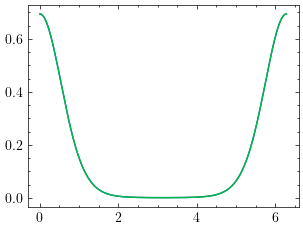

In [9]:
plt.plot(x_vals, solver.reconstruction(solver.bar_mu_k, x_vals))
plt.plot(x_vals, (desired_distribution(2))(x_vals))
plt.show()

In [10]:
derivative_coeffs = 1j * solver.k_vals * solver.bar_mu_k
# The following should be approximately 0.
np.linalg.norm((solver.sigma * solver.D + solver.K)@derivative_coeffs)

np.float64(6.450348465880242e-14)

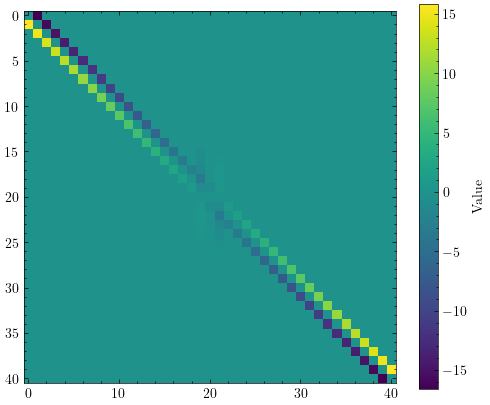

In [11]:
plt.figure(figsize=(6, 5))
im = plt.imshow(np.real(solver.K), cmap='viridis', aspect='equal')

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Value')

# Cheching the symmetry

In [313]:
def compute_M(func, d, L, N):
    # Use a periodic grid (endpoint not included) and evaluate f(x)
    x = np.linspace(0, d, N, endpoint=False)
    f_vals = func(x)
    dx = d / N

    # Fourier mode indices and number of modes
    k_vals = np.arange(-L, L+1)
    n_modes = len(k_vals)

    # Initialize U array
    U = np.empty((n_modes, N), dtype=complex)
    for idx, k in enumerate(k_vals):
        if k == 0:
            U[idx, :] = (x - d/2)/np.sqrt(d)
        else:
            U[idx, :] = np.sqrt(d) / (2 * np.pi * 1j * k) * np.exp(2 * np.pi * 1j * k * x / d)

    # Center each primitive U_k so that its weighted mean (with weight 1/f) is zero.
    denominator = np.sum((1 / f_vals) * dx)
    weighted_mean = np.sum(U / f_vals * dx, axis=1) / denominator
    U = U - weighted_mean[:, None]

    # Build the Gram matrix using the inner product
    # M_{ij} = ∫ (conjugate(U_i) U_j)/f dx.
    M = np.einsum('ik,jk->ij', np.conjugate(U) / f_vals, U) * dx
    return M

def compute_M_analytic(c, L, num_points=1000):
    """
    Compute the Gram matrix M with entries
        M_{mn} = ∫₀^(2π) (conjugate(U_m(x)) U_n(x))/q(x) dx,
    where the primitives U_k are defined by:
      - For k != 0:
          U_k(x) = 1/(ik√(2π)) * (e^(ikx) - I_|k|(c)/I_0(c))
      - For k = 0:
          U_0(x) = x/√(2π) - √(π/2),
        which is the unique representative satisfying
          ∫₀^(2π) (U_0(x))/(q(x)) dx = 0.
    Here, q(x) = exp(c cos x)/Z with Z = 2π I_0(c) so that
          1/q(x) = Z * exp(-c cos x).
    
    For nonzero indices, one may show that:
          M_{mn} = Z/(m*n) * [iv(n-m, c) - iv(|m|, c)*iv(|n|, c)/iv(0, c)].
    
    For indices with m = 0 or n = 0 we compute the integral numerically.
    
    Parameters:
      c         : positive constant in the weight.
      L         : maximum Fourier mode (m and n in {-L, ..., L}).
      num_points: number of points for numerical integration when needed.
    
    Returns:
      M         : real matrix of shape (2L+1, 2L+1).
    """
    # Fourier mode indices: -L, ..., L.
    k_vals = np.arange(-L, L+1)
    n_modes = len(k_vals)
    
    # Normalization constant for 1/q.
    Z = 1.0/(2*np.pi*iv(0, c))
    
    # Allocate Gram matrix.
    M = np.zeros((n_modes, n_modes), dtype=np.complex128)
    
    # Define U_k(x) for any mode k.
    def U_k(x, k):
        # x can be an array.
        if k == 0:
            # Use the unique representative:
            return x/np.sqrt(2*np.pi) - np.sqrt(np.pi/2)
        else:
            return (1/(1j*k*np.sqrt(2*np.pi)))*(np.exp(1j*k*x) - bessel(abs(k), c)/bessel(0, c))
    
    # Weight function 1/q(x) = Z * exp(-c cos x).
    def weight(x):
        return Z * np.exp(-c*np.cos(x))
    
    # Precompute x grid for numerical integration (for zero-mode rows/columns)
    xs = np.linspace(0, 2*np.pi, num_points, endpoint=False)
    dx = 2*np.pi/num_points
    
    # For indices where both modes are nonzero, use the analytic formula.
    for i, m in enumerate(k_vals):
        for j, n in enumerate(k_vals):
            if m != 0 and n != 0:
                # Use the derived analytic expression.
                term = bessel(n-m, c) - (bessel(abs(m), c)*bessel(abs(n), c))/bessel(0, c)
                M[i,j] = Z/(m*n) * term
            else:
                # For m=0 or n=0, compute the integral numerically.
                # Define the integrand: (conjugate(U_m(x))*U_n(x))*weight(x)
                integrand = np.conjugate(U_k(xs, m)) * U_k(xs, n) * weight(xs)
                M[i,j] = np.sum(integrand)*dx
                # Force M to be real (the imaginary part should vanish by symmetry).
                M[i,j] = M[i,j].real

    return M

def compute_L_H_minus1(M, K):
    M_reduced = np.delete(np.delete(M, M.shape[0] // 2, axis=0), M.shape[0] // 2, axis=1)
    K_reduced = np.delete(np.delete(K, K.shape[0] // 2, axis=0), K.shape[0] // 2, axis=1)
    return M_reduced @ K_reduced, M_reduced

In [320]:
K = 1.1
L = 50
w_true = np.zeros(2*L+1)
w_true[L+1], w_true[L-1] = -K*np.sqrt(2*np.pi)/2, -K*np.sqrt(2*np.pi)/2
# I am going to use the theoretical representation of q(theta) using Bessel.
solver = McKeanVlasovSolver(L=L, d=2*np.pi, G=G, alpha=[alpha1], 
                            W=W(K=K), mu_0=lambda x: np.ones_like(x)/(2*np.pi), min_fourier_samples=5000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1], 
                            state_weight=1000, sigma=0.5, 
                            final_distribution=np.sqrt(2*np.pi)*np.array([bessel(idx, 2*K*unique_r(K)) for idx in range(-L, L+1)])/Z(K),
                            w_coeffs=w_true
                           )
linear_operator = -(solver.L_G + solver.K + solver.sigma * solver.D)

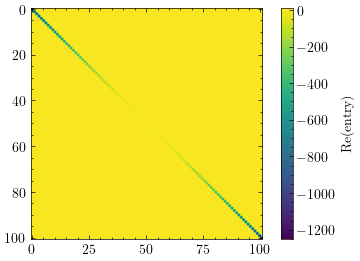

In [321]:
plt.figure(figsize=(5, 3))
plt.imshow(np.real(linear_operator), cmap='viridis', aspect='equal')
plt.colorbar(label='Re(entry)')

In [322]:
M = compute_M(desired_distribution(K=K), d=solver.d, L=solver.L, N=10000)
M_true = compute_M_analytic(2*K*unique_r(K), L=solver.L)
linear_operator_symmetric, M_reduced = compute_L_H_minus1(M, linear_operator)

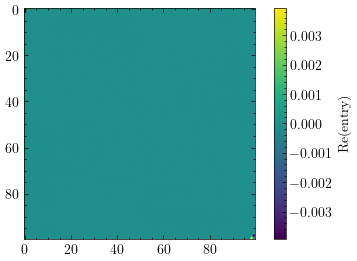

In [323]:
plt.figure(figsize=(5, 3))
plt.imshow(np.real(linear_operator_symmetric - np.conjugate(linear_operator_symmetric).T), cmap='viridis', aspect='equal')
plt.colorbar(label='Re(entry)')

In [324]:
linear_operator_symmetric = 0.5 * (linear_operator_symmetric + np.conjugate(linear_operator_symmetric.T))
eigenvalues, eigenvectors = eigh(linear_operator_symmetric, M_reduced)
eigenvalues = np.real(eigenvalues)
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [325]:
eigenvalues

array([-1.24737626e+03, -1.24737626e+03, -1.20061750e+03, -1.20061750e+03,
       -1.15205105e+03, -1.15205105e+03, -1.10455170e+03, -1.10455170e+03,
       -1.05805170e+03, -1.05805170e+03, -1.01255170e+03, -1.01255170e+03,
       -9.68051701e+02, -9.68051701e+02, -9.24551702e+02, -9.24551702e+02,
       -8.82051702e+02, -8.82051702e+02, -8.40551702e+02, -8.40551702e+02,
       -8.00051703e+02, -8.00051703e+02, -7.60551703e+02, -7.60551703e+02,
       -7.22051704e+02, -7.22051704e+02, -6.84551704e+02, -6.84551704e+02,
       -6.48051705e+02, -6.48051705e+02, -6.12551705e+02, -6.12551705e+02,
       -5.78051706e+02, -5.78051706e+02, -5.44551707e+02, -5.44551707e+02,
       -5.12051708e+02, -5.12051708e+02, -4.80551708e+02, -4.80551708e+02,
       -4.50051709e+02, -4.50051709e+02, -4.20551710e+02, -4.20551710e+02,
       -3.92051712e+02, -3.92051712e+02, -3.64551713e+02, -3.64551713e+02,
       -3.38051714e+02, -3.38051714e+02, -3.12551716e+02, -3.12551716e+02,
       -2.88051718e+02, -